# Theory

Image sharpening is a technique in digital image processing used to enhance the edges and fine details within an image. This is typically achieved by applying a convolution filter (kernel) that emphasizes high-frequency components, making transitions between different regions more distinct. In this lab, a sharpening filter is implemented using a $3 \times 3$ kernel:

$$
\text{Sharpening Kernel} = \begin{bmatrix}
-\frac{1}{9} & -\frac{1}{9} & -\frac{1}{9} \\
-\frac{1}{9} & \frac{8}{9} & -\frac{1}{9} \\
-\frac{1}{9} & -\frac{1}{9} & -\frac{1}{9}
\end{bmatrix}
$$

This kernel enhances the center pixel while subtracting the surrounding pixels, thus highlighting edges and transitions. The process involves padding the image, applying the filter to each pixel, and reconstructing the sharpened image.


In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
def sharp_filter(input_image):
  img = input_image.resize((400,400), Image.Resampling.LANCZOS)

  fig = plt.figure()
  fig.set_figheight(10)
  fig.set_figwidth(10)

  #plotting original image
  fig.add_subplot(1,2,1)
  plt.imshow(img, cmap='gray')
  plt.title('original')


  # convert to numpy array 
  numpy_image = np.array(img)
  # array for padding
  array_b = np.zeros((402,402))

  # to pad initial array with zeros in all side
  array_b[1:401,1:401] = numpy_image

  #defining filter
  filter_array = np.array([[-1/9,-1/9,-1/9],
                         [-1/9,8/9,-1/9],
                         [-1/9,-1/9,-1/9]])
  
  #creating empty list
  lst = []

  for i in range(400):
    for j in range(400):
      #extracting part of array equal to filter size
      array_c = array_b[i:(3+i),j:(3+j)]
    
     #applying filter
      array_mul = np.multiply(filter_array,array_c)
      array_sum = np.sum(array_mul)
    
      # putting calculated value in list
      lst.append(array_sum)

  # resizing lst to shape of original array
  final_array = np.resize(lst,(400,400))

  final_image = Image.fromarray(final_array)
  final_image= final_image.convert("L")

    #plotting filtered image
  fig.add_subplot(1,2,2)
  plt.imshow(final_image, cmap='gray')
  plt.title('filtered image')
  

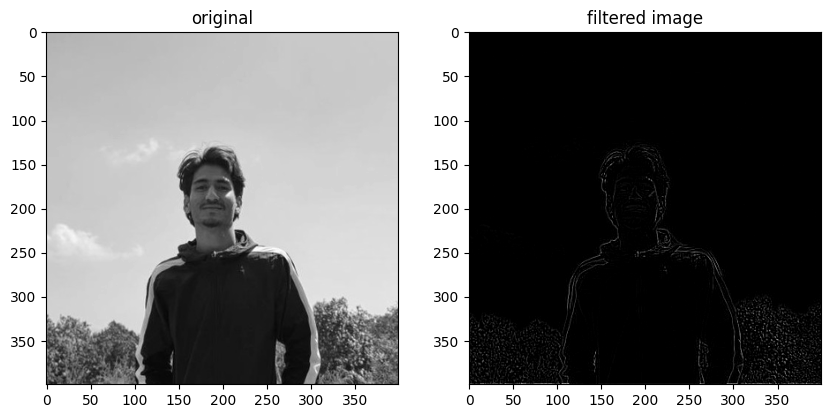

: 

In [ ]:
# reading image and converting to gray scale
img = Image.open('img/prakash.jpg').convert('L')
# Sharpen the image
sharp_filter(img)


# Conclusion

The sharpening filter successfully enhances the edges and details in the input image, making features more pronounced. By applying a convolution operation with a suitable kernel, we can effectively improve image clarity and highlight important structures. This technique is fundamental in image processing applications such as medical imaging, object detection, and computer vision.